# Q8 — Does rating consistency or level vary by cuisine?

**The data problem first.** Each platform speaks its own cuisine vocabulary, and nobody
reconciled them: Tripadvisor uses Italian *feminine* adjectives (`Italiana`), TheFork
*masculine* (`Italiano`) plus regional Italians, and Google an English `primary_type`/`types[]`
controlled vocabulary (`italian_restaurant`). The old `primary_cuisine` took Tripadvisor's
first label, else TheFork's — so the *same* cuisine split into separate rows
(`Italiana` vs `Italiano`), Google's near-complete coverage was ignored, and only the
**first** of each venue's several cuisines survived.

The integration step (`transform/unified_dataset/cuisine.py`) now maps every raw label to a
small **canonical cuisine list** and reconciles them per venue into `cuisine_tags` (the full
set) + `cuisine_primary` (most specific bucket wins; ties → Tripadvisor > TheFork > Google).
Q8 groups by that canonical bucket.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


In [2]:
# The integration win: cuisine coverage before vs after reconciling all three vocabularies.
cov = publish(run(queries.q8_coverage()), "q8_cuisine_coverage",
              "Q8 — Cuisine coverage before/after canonical reconciliation.").iloc[0]
print(f"cuisine coverage: {cov.pct_old:.1f}% (raw TA/TF first label) "
      f"-> {cov.pct_canonical:.1f}% (canonical, Google included)")
print(f"labels: {int(cov.old_distinct_labels)} raw -> {int(cov.canonical_buckets)} canonical buckets")

cuisine coverage: 34.2% (raw TA/TF first label) -> 93.4% (canonical, Google included)
labels: 73 raw -> 31 canonical buckets


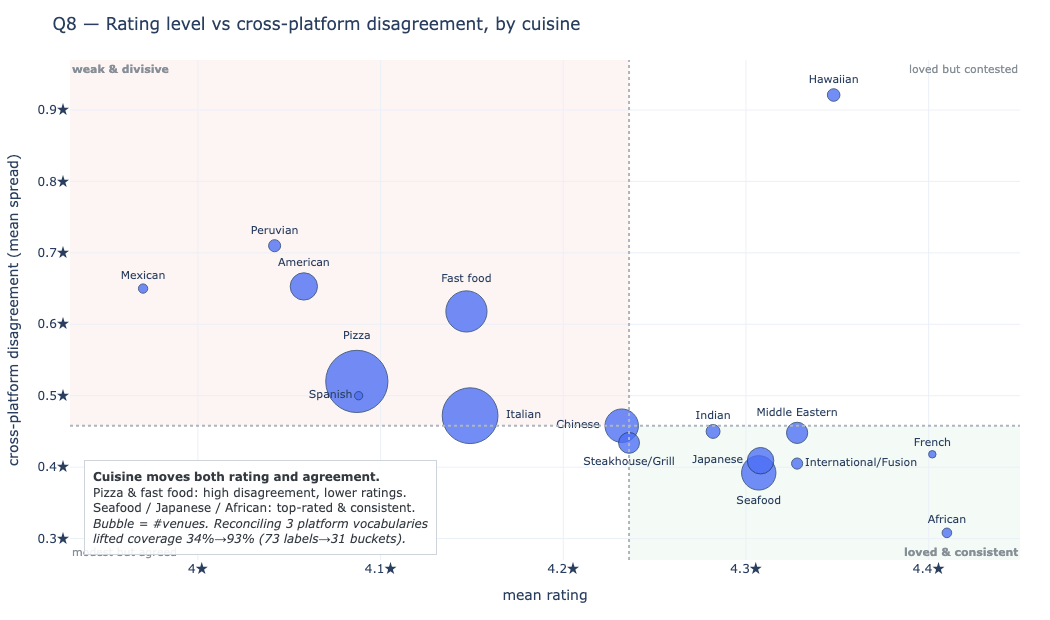

,cuisine,restaurants,mean_rating,multi_platform,mean_range,median_range,tp
1,Pizza,1463,4.087,861,0.520,0.40,top center
2,Italian,1176,4.149,1013,0.472,0.40,middle right
3,Fast food,640,4.147,207,0.618,0.50,top center
4,Seafood,446,4.307,381,0.392,0.40,bottom center
5,Chinese,423,4.232,312,0.458,0.40,middle left
6,American,281,4.058,139,0.653,0.50,top center
7,Japanese,265,4.308,156,0.409,0.30,middle left
8,Middle Eastern,170,4.328,49,0.448,0.40,top center
9,Steakhouse/Grill,165,4.236,125,0.434,0.40,bottom center
10,Indian,73,4.282,51,0.450,0.30,top center


In [3]:
# Headline: rating level vs cross-platform disagreement, one point per cuisine.
# Café/Bakery/Bar is a format (and the largest bucket), not a cuisine -> excluded here;
# require >= 20 multi-platform venues so the spread is reliable.
q8 = publish(run(queries.q8_cuisine()), "q8_cuisine_consistency",
             "Q8 — Mean rating and cross-platform spread by canonical cuisine.")
d = q8[(q8.cuisine != "Café/Bakery/Bar") & (q8.multi_platform >= 20)].copy()
mx, my = d.mean_rating.median(), d.mean_range.median()

# Nudge labels apart in the dense high-rating / low-spread cluster.
POS = {"Seafood": "bottom center", "Japanese": "middle left",
       "International/Fusion": "middle right", "Middle Eastern": "top center",
       "Chinese": "middle left", "Steakhouse/Grill": "bottom center",
       "Italian": "middle right", "Indian": "top center", "Spanish": "middle left"}
d["tp"] = d.cuisine.map(POS).fillna("top center")

fig = px.scatter(d, x="mean_rating", y="mean_range", size="restaurants", text="cuisine",
                 size_max=44, template="plotly_white")
fig.update_traces(textposition=d["tp"], marker_color="#4C6EF5", marker_opacity=0.78,
                  marker_line_color="#1B3A6B", marker_line_width=1, textfont_size=11,
                  cliponaxis=False)

x0, x1, y0, y1 = 3.93, 4.45, 0.27, 0.97
fig.add_shape(type="rect", x0=mx, x1=x1, y0=y0, y1=my, fillcolor="#2F9E44",
              opacity=0.05, line_width=0, layer="below")
fig.add_shape(type="rect", x0=x0, x1=mx, y0=my, y1=y1, fillcolor="#E03131",
              opacity=0.05, line_width=0, layer="below")
fig.add_vline(x=mx, line_dash="dot", line_color="#ADB5BD")
fig.add_hline(y=my, line_dash="dot", line_color="#ADB5BD")
qa = dict(showarrow=False, font=dict(size=11, color="#868E96"), xref="x", yref="y")
fig.add_annotation(x=x1, y=y0, text="<b>loved & consistent</b>", xanchor="right", yanchor="bottom", **qa)
fig.add_annotation(x=x0, y=y1, text="<b>weak & divisive</b>", xanchor="left", yanchor="top", **qa)
fig.add_annotation(x=x0, y=y0, text="modest but agreed", xanchor="left", yanchor="bottom", **qa)
fig.add_annotation(x=x1, y=y1, text="loved but contested", xanchor="right", yanchor="top", **qa)
fig.add_annotation(xref="paper", yref="paper", x=0.015, y=0.20, xanchor="left", yanchor="top",
    align="left", showarrow=False, borderpad=8, borderwidth=1, bordercolor="#CED4DA",
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=12, color="#343A40"),
    text=(f"<b>Cuisine moves both rating and agreement.</b><br>"
          f"Pizza &amp; fast food: high disagreement, lower ratings.<br>"
          f"Seafood / Japanese / African: top-rated &amp; consistent.<br>"
          f"<i>Bubble = #venues. Reconciling 3 platform vocabularies<br>"
          f"lifted coverage {cov.pct_old:.0f}%→{cov.pct_canonical:.0f}% "
          f"({int(cov.old_distinct_labels)} labels→{int(cov.canonical_buckets)} buckets).</i>"))
fig.update_xaxes(title="mean rating", ticksuffix="★", range=[x0, x1])
fig.update_yaxes(title="cross-platform disagreement (mean spread)", ticksuffix="★", range=[y0, y1])
fig.update_layout(title="Q8 — Rating level vs cross-platform disagreement, by cuisine",
                  width=1050, height=640, showlegend=False, margin=dict(l=70, r=30, t=60, b=60))
fig.show()
d

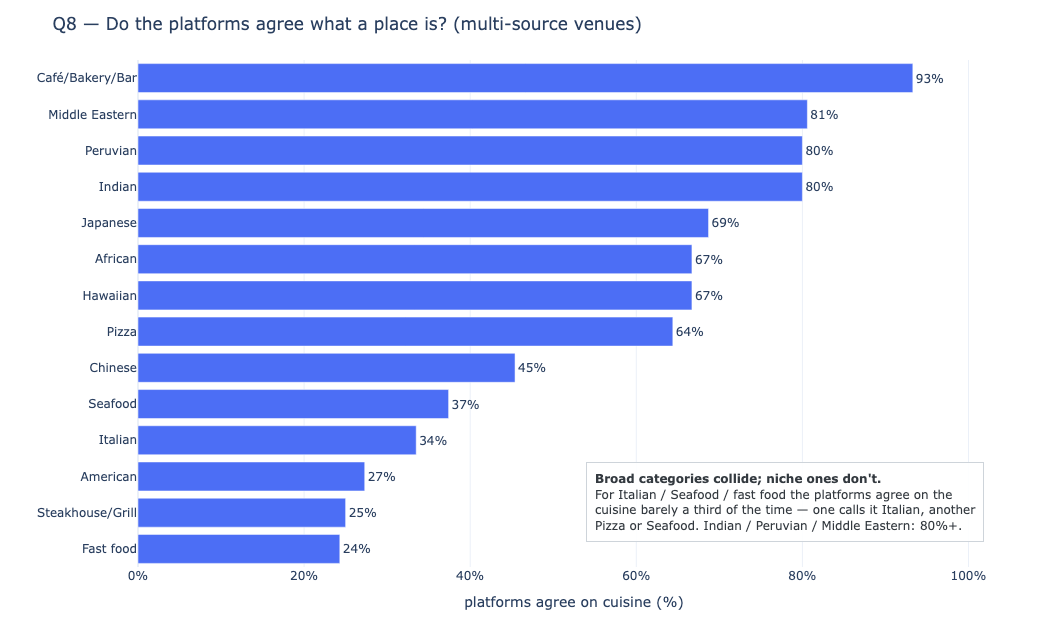

,cuisine,multi_source,pct_agree
0,Café/Bakery/Bar,30,93.3
1,Middle Eastern,31,80.6
2,Indian,45,80.0
3,Peruvian,25,80.0
4,Japanese,147,68.7
5,Hawaiian,21,66.7
6,African,21,66.7
7,Pizza,807,64.4
8,Chinese,273,45.4
9,Seafood,329,37.4


In [4]:
# Bonus finding: do the platforms even agree what a place *is*? For venues carrying a
# cuisine on >= 2 platforms, how often do their primary buckets match?
agr = publish(run(queries.q8_cuisine_agreement()), "q8_cuisine_agreement",
              "Q8 — Cross-source agreement on the primary cuisine, by bucket.")
a = agr.sort_values("pct_agree")
fig2 = px.bar(a, x="pct_agree", y="cuisine", orientation="h", text="pct_agree",
              template="plotly_white")
fig2.update_traces(marker_color="#4C6EF5", texttemplate="%{text:.0f}%", textposition="outside")
fig2.add_annotation(xref="paper", yref="paper", x=0.97, y=0.05, xanchor="right", yanchor="bottom",
    align="left", showarrow=False, borderpad=8, borderwidth=1, bordercolor="#CED4DA",
    bgcolor="rgba(255,255,255,0.88)", font=dict(size=12, color="#343A40"),
    text=("<b>Broad categories collide; niche ones don't.</b><br>"
          "For Italian / Seafood / fast food the platforms agree on the<br>"
          "cuisine barely a third of the time — one calls it Italian, another<br>"
          "Pizza or Seafood. Indian / Peruvian / Middle Eastern: 80%+."))
fig2.update_xaxes(title="platforms agree on cuisine (%)", ticksuffix="%", range=[0, 105])
fig2.update_yaxes(title="")
fig2.update_layout(title="Q8 — Do the platforms agree what a place is? (multi-source venues)",
                   width=1000, height=560, margin=dict(l=120, r=40, t=60, b=50))
fig2.show()
agr

**Answer (Q8): yes — cuisine moves both the rating *level* and the cross-platform
*consistency*, but only after the cuisine field is fixed.** Reconciling the three platform
vocabularies into a canonical taxonomy lifts cuisine coverage from ~34% to ~93% and collapses
73 raw labels into 31 buckets — without it the question can't be answered honestly (the
modal cuisine was split across `Italiana`/`Italiano` and Google was ignored).

On the clean buckets: high-throughput, broad-appeal categories (**pizza**, **fast food**,
**American**) sit at lower ratings *and* the widest cross-platform disagreement, while
**seafood**, **Japanese** and **African** are both top-rated and the most consistent. A second
effect surfaces from `cuisine_agreement`: the platforms disagree on *what a place even is* far
more for broad categories (Italian/Seafood ≈ a third agreement) than for niche cuisines
(Indian, Peruvian, Middle Eastern 80%+) — the disagreement is partly a labelling problem, not
just a rating one. See `q8_cuisine_consistency`, `q8_cuisine_agreement`, `q8_cuisine_coverage`.